Benchmark
============

Adding all planners
===========


In [4]:
import matplotlib.pylab as plt
%matplotlib inline
from IPPerfMonitor import IPPerfMonitor

#import IPBasicPRM
#import IPVISBasicPRM

#import IPVisibilityPRM
#import IPVISVisibilityPRM

import IPLazyPRM
import IPVISLazyPRM

#import IPRRT
#import IPVISRRT

import IPAStar
import AStarReopening
import IPVISAStar

## Eingabe der Parameter

1  Diskretisierungsstufen

2. Kollision der Verbindungen An/Aus?

3. Reopening An/Aus?

4. Vergleich alles mit LazyPRM

Set-up of the test scenario and the configuration for all planner
===================================

Following a procedure to compare all discussed planners are shown:

1. Configuration for every planner is defined
2. The configuration and the planner is stored in the variable setup, a Python dict()
3. the variable setup is then used to uniformly call the planning calls


In [1]:
def compute_path_lengths_multi(graph, solution, theta_in_radians=True):
    """
    Berechnet die Gesamtpfadläng pro Roboter in einem Graphen mit mehreren Robotern

    Das Knotenattribut 'pos' ist eine sequenz [x1,y1,theta1, x2,y2,theta2,...]
    Für unsere zwei Roboter sind es 6 Einträge pro Knoten.
    Die Funktion summiert die euklidischen Distanzen zwischen jedem Knotenpaar (Kanten) in der xy-Ebene für jeden Roboter auf.
    """
    import numpy as np
    import networkx as nx

    # Falls keine Lösung oder nur ein Knoten vorhanden ist, sofort Nullwerte zurückgeben
    if not solution or len(solution) < 2:
        return {
            'green': {'total': 0.0},
            'red': {'total': 0.0},
            'segments': 0
        }

    # Hole alle 'pos' Attribute aus dem Graph (dict: node -> config)
    pos_attr = nx.get_node_attributes(graph, 'pos')
    total_g = 0.0  # aufsummierte Distanz für grünen Roboter (Roboter 1)
    total_r = 0.0  # aufsummierte Distanz für roten Roboter (Roboter 2)
    segments = 0   # Anzahl der Segmente (Anzahl Kanten im Pfad)

    # Iteriere über alle aufeinanderfolgenden Knotenpaare der Lösung
    for i in range(len(solution) - 1):
        a = solution[i]; b = solution[i + 1]
        # Fehler, falls ein Knoten kein 'pos' Attribut hat (schützt vor inkonsistenten Graphen)
        if a not in pos_attr or b not in pos_attr:
            raise ValueError(f"Node {a} or {b} missing 'pos' attribute in graph")
        pa = np.array(pos_attr[a], dtype=float)  # Konfiguration an Knoten a
        pb = np.array(pos_attr[b], dtype=float)  # Konfiguration an Knoten b

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 1 (grün)
        # pa[0:2] und pb[0:2] sind [x1,y1] für Roboter 1
        total_g += float(np.linalg.norm(pb[0:2] - pa[0:2]))

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 2 (rot)
        # pa[3:5] und pb[3:5] sind [x2,y2] für Roboter 2
        total_r += float(np.linalg.norm(pb[3:5] - pa[3:5]))

        segments += 1  # ein weiteres Kanten-Segment wurde betrachtet

    # Rückgabe: pro Roboter nur die 'total' Länge (Rotationen werden hier bewusst nicht berücksichtigt)
    return {
        'green': {'total': total_g},
        'red': {'total': total_r},
        'segments': segments
    }

In [2]:
import matplotlib.animation as animation
from IPython.display import HTML, display
import copy
import numpy as np
import matplotlib.pyplot as plt

# Hilfsfunktion (unverändert, aber wir behandeln den Rückgabewert jetzt besser)
def _interpolate_line(startPos, endPos, step_l):
    steps = []
    line = np.array(endPos) - np.array(startPos)
    line_l = np.linalg.norm(line)
    if line_l == 0:
        return [np.array(startPos)]
    step = line / line_l * step_l
    n_steps = int(np.floor(line_l / step_l))
    c_step = np.array(startPos, dtype=float)
    for i in range(n_steps):
        steps.append(copy.deepcopy(c_step))
        c_step = c_step + step
    if not np.allclose(c_step, np.array(endPos)):
        steps.append(np.array(endPos, dtype=float))
    return steps

def animate_solution_multi_downsampled(prm, environment, solution, visualizer=None, 
                                     workSpaceLimits=None, step_l=0.1, interval=50, 
                                     max_frames=250, figsize=(6,6), dpi=70, 
                                     pause_frames=40):
    
    # 1. Basic Checks
    if not solution or len(solution) < 2:
        raise ValueError('solution must contain at least two nodes')

    # 1. Récupération des positions pour l'interpolation du robot
    path_pos = [prm.graph.nodes[n]['pos'] for n in solution]
    
    # Interpolation (Mouvement fluide du point rouge)
    full_path = [path_pos[0]]
    for i in range(1, len(path_pos)):
        s, e = np.array(path_pos[i-1]), np.array(path_pos[i])
        dist = np.linalg.norm(e - s)
        if dist > 0:
            n_steps = int(np.floor(dist / step_l))
            for j in range(1, n_steps + 1):
                full_path.append(s + (e - s) * (j / (n_steps + 1)))
    full_path.append(path_pos[-1])

    # Downsampling
    if len(full_path) > max_frames:
        indices = np.linspace(0, len(full_path)-1, max_frames).astype(int)
        frames_data = [full_path[i] for i in indices]
    else:
        frames_data = full_path

    # 2. Setup Figure
    fig_local, ax = plt.subplots(figsize=figsize, dpi=dpi)
    limits = environment.getEnvironmentLimits()

    def _animate(current_pos):
        ax.cla() # On efface pour redessiner proprement
        
        # --- APPEL DU VISUALISEUR OFFICIEL ---
        # C'est ici que les points bleus et le chemin vert sont dessinés
        # exactement comme dans vos figures statiques.
        visualizer(prm, solution, ax=ax, nodeSize=100)
        
        # On redessine les obstacles par sécurité
        environment.drawObstacles(ax)
        
        # On remet les limites (parce que visualizer peut les changer)
        ax.set_xlim(limits[0])
        ax.set_ylim(limits[1])
        ax.set_title("A* Official Visualization & Animation")

        # --- AJOUT DU ROBOT ROUGE ---
        ax.plot(current_pos[0], current_pos[1], 'o', color='red', 
                markersize=12, markeredgecolor='black', zorder=10)

    print(f"Rendu de l'animation avec le visualiseur officiel...")
    ani = animation.FuncAnimation(fig_local, _animate, frames=frames_data, interval=interval)
    
    html = HTML(ani.to_jshtml())
    display(html)
    plt.close()
    return ani

In [5]:
plannerFactory = dict()

#basicConfig = dict()
#basicConfig["radius"] = 3
#basicConfig["numNodes"] = 200
#plannerFactory["basePRM"] = [IPBasicPRM.BasicPRM, basicConfig, IPVISBasicPRM.basicPRMVisualize]

#visbilityConfig = dict()
#visbilityConfig["ntry"] = 300
#plannerFactory["visibilityPRM"] = [IPVisibilityPRM.VisPRM, visbilityConfig, IPVISVisibilityPRM.visibilityPRMVisualize ]

#lazyConfig = dict()
#lazyConfig["initialRoadmapSize"] = 10
#lazyConfig["updateRoadmapSize"]  = 5 
#lazyConfig["kNearest"] = 8
#lazyConfig["maxIterations"] = 20
#plannerFactory["lazyPRM"] = [IPLazyPRM.LazyPRM, lazyConfig, IPVISLazyPRM.lazyPRMVisualize]

#astarConfig = dict()
#astarConfig["heuristic"] = 'euclidean' 
#astarConfig["w"]  = 0.5
#astarConfig["num_steps"] = [22, 44]
#astarConfig["checkEdgeCollision"] = False
#plannerFactory["astar"] = [IPAStar.AStar, astarConfig, IPVISAStar.aStarVisualize]

astarConfig = dict()
astarConfig["heuristic"] = 'euclidean' 
astarConfig["w"]  = 0.1
astarConfig["num_steps"] = [50, 100]
astarConfig["checkEdgeCollision"] = False
plannerFactory["astar"] = [IPAStar.AStar, astarConfig, IPVISAStar.aStarVisualize]

astarConfig2 = dict()
astarConfig2["heuristic"] = 'euclidean' 
astarConfig2["w"]  = 0.7
astarConfig2["num_steps"] = [50, 100]
astarConfig2["checkEdgeCollision"] = False
plannerFactory["astar2"] = [IPAStar.AStar, astarConfig2, IPVISAStar.aStarVisualize]

#astarConfig2 = dict()
#astarConfig2["heuristic"] = 'euclidean' 
#astarConfig2["w"]  = 0.7
#astarConfig2["num_steps"] = [50, 100]
#astarConfig2["checkEdgeCollision"] = False
#plannerFactory["astar2"] = [AStarReopening.ReopenAStar, astarConfig2, IPVISAStar.aStarVisualize]

lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 10
lazyConfig["updateRoadmapSize"]  = 5 
lazyConfig["kNearest"] = 8
lazyConfig["maxIterations"] = 20
plannerFactory["lazyPRM"] = [IPLazyPRM.LazyPRM, lazyConfig, IPVISLazyPRM.lazyPRMVisualize]




In [6]:
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

In [7]:
import IPTestSuite as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting


In [7]:
#import importlib
#importlib.reload(IPTestSuiteSS2024)

In [8]:
fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)

Trap
Bottleneck
Fat bottleneck
MyField


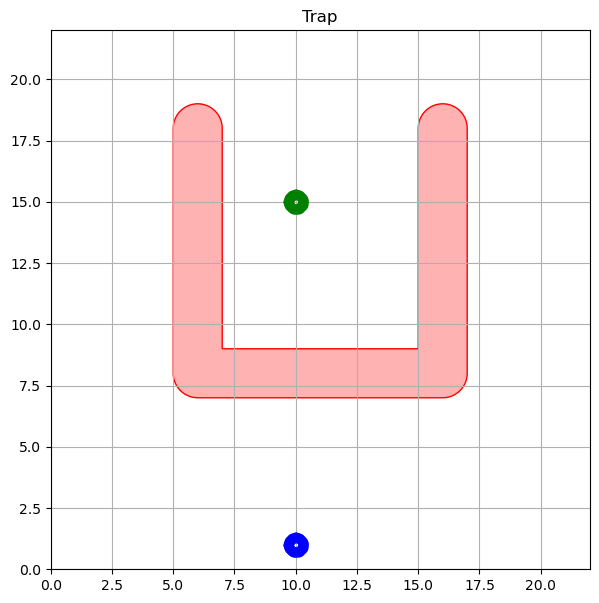

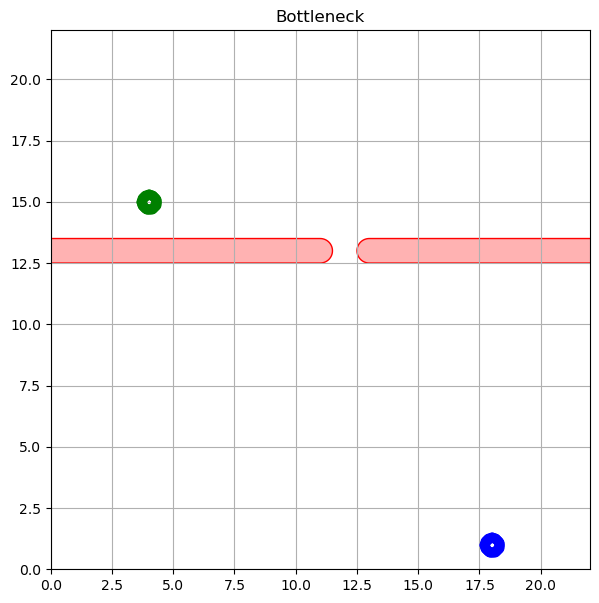

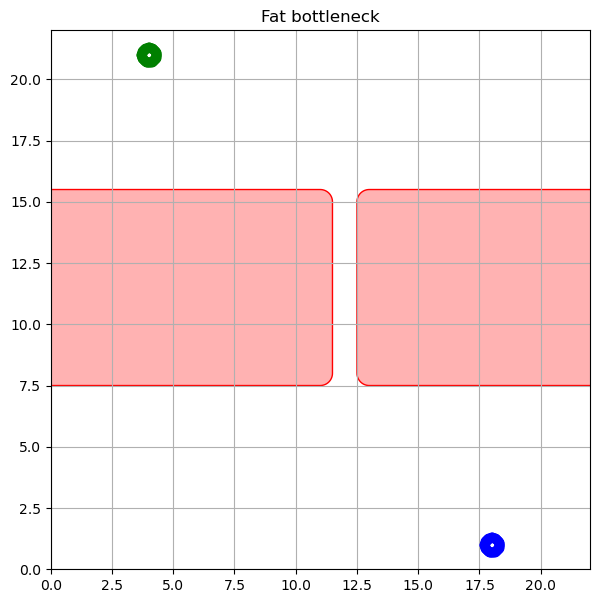

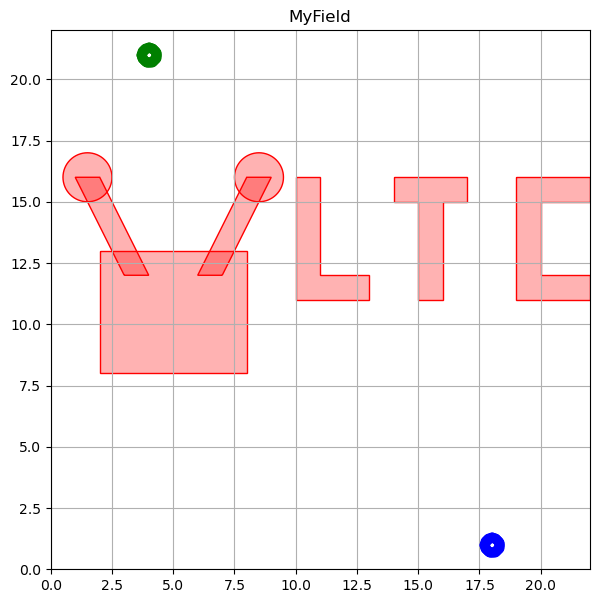

In [9]:
for benchmark in fullBenchList:
    fig_local = plt.figure(figsize=(7,7))
    ax = fig_local.add_subplot(1,1,1)
    title = benchmark.name
    ax.set_title(title)
    ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
    ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
    plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
    plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
    #try:
    benchmark.collisionChecker.drawObstacles(ax)
  
        
    #except Exception as e:
    #    print ("Error", e)
    #    pass
    plt.show()

In [10]:
resultList = list()
testList = fullBenchList

for key,producer in list(plannerFactory.items()):
    print(key, producer)
    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        #planner = IPBasicPRM.BasicPRM(benchmark.collisionChecker)
        planner = producer[0](benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            
            resultList.append(ResultCollection(key,
                                          planner, 
                                           benchmark, 
                                           planner.planPath(benchmark.startList,benchmark.goalList,producer[1]),
                                           IPPerfMonitor.dataFrame()
                                          ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            pass



astar [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.1, 'num_steps': [50, 100], 'checkEdgeCollision': False}, <function aStarVisualize at 0x000001F5577DEE80>]
Planning: astar - Trap
Planning: astar - Bottleneck
Planning: astar - Fat bottleneck
Planning: astar - MyField
astar2 [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.7, 'num_steps': [50, 100], 'checkEdgeCollision': False}, <function aStarVisualize at 0x000001F5577DEE80>]
Planning: astar2 - Trap
Planning: astar2 - Bottleneck
Planning: astar2 - Fat bottleneck
Planning: astar2 - MyField
lazyPRM [<class 'IPLazyPRM.LazyPRM'>, {'initialRoadmapSize': 10, 'updateRoadmapSize': 5, 'kNearest': 8, 'maxIterations': 20}, <function lazyPRMVisualize at 0x000001F5577DE020>]
Planning: lazyPRM - Trap
Planning: lazyPRM - Bottleneck
Planning: lazyPRM - Fat bottleneck
Planning: lazyPRM - MyField


In [ ]:
import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(20,20))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        #IPVISBasicsPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
    except Exception as e:
        print ("Error", e)
        pass
    
    plt.show()


'""\nfor result in resultList:\n    \n    fig_local = plt.figure(figsize=(20,20))\n    ax = fig_local.add_subplot(1,1,1)\n    title = result.plannerFactoryName + " - " + result.benchmark.name\n    if result.solution == []:\n        title += " (No path found!)"\n    title += "\n Assumed complexity level " + str(result.benchmark.level)\n    ax.set_title(title)\n    try:\n        #IPVISBasicsPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))\n        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)\n    except Exception as e:\n        print ("Error", e)\n        pass\n    \n    plt.show()\n'

In [12]:
for bench in testList:
    for result in resultList:
        if result.benchmark.name == bench.name:
            if result.solution is not None :
                print(result.plannerFactoryName)
                animate_solution_multi_downsampled(
                    result.planner, bench.collisionChecker, result.solution,
                    visualizer=plannerFactory[result.plannerFactoryName][2],
                    step_l=0.4, interval=60, max_frames=80, figsize=(20,20), dpi=50)

astar
Rendu de l'animation avec le visualiseur officiel...


KeyboardInterrupt: 

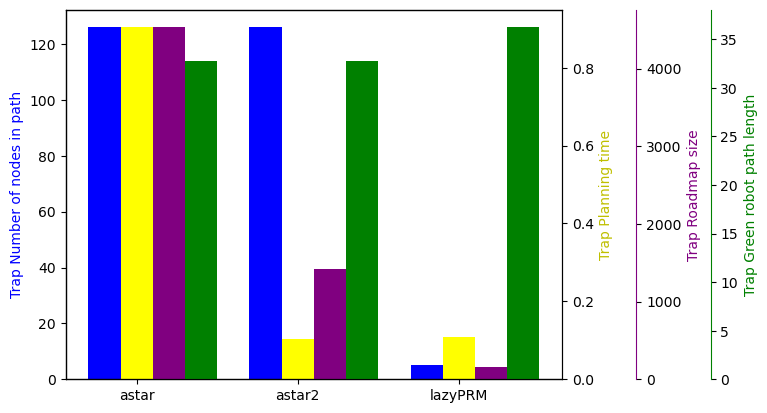

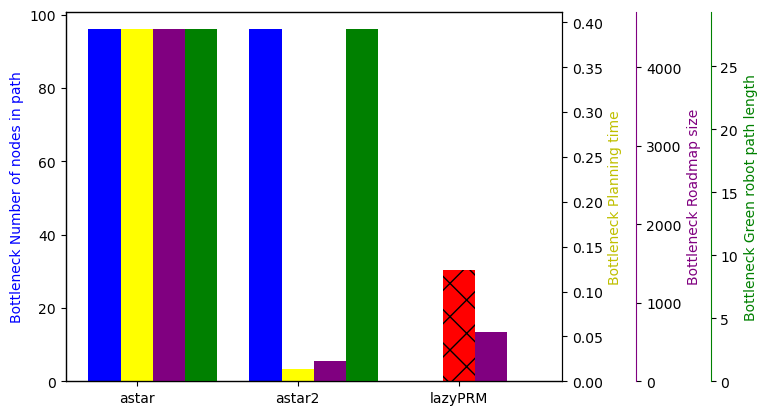

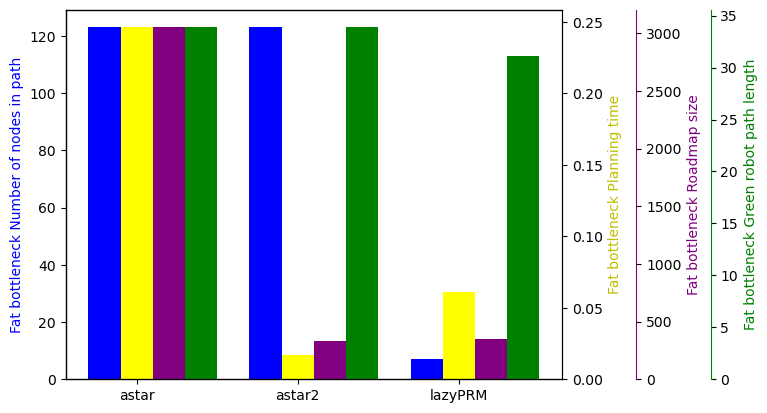

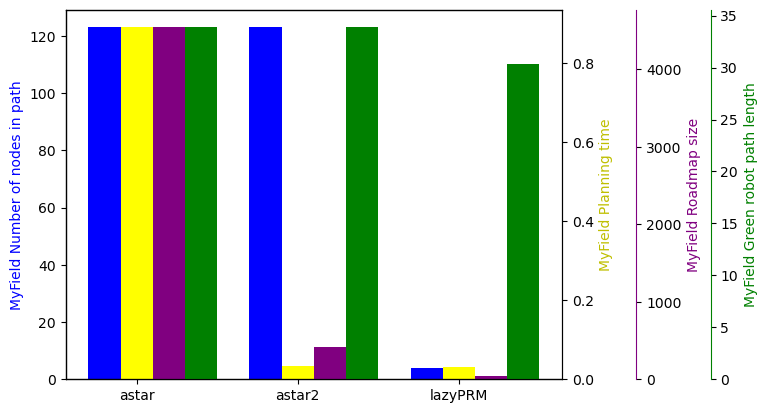

In [11]:
import numpy as np
for bench in testList:
    title = bench.name
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    res=dict()
    
    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()
                res[result.plannerFactoryName] = compute_path_lengths_multi(result.planner.graph, result.solution, theta_in_radians=True)


        fig, ax = plt.subplots()

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " Number of nodes in path", color="blue")
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys())

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " Planning time", color="y")

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")

        ax4 = ax.twinx()
        ax4.bar(np.arange(len(pathLength.keys()))+3*width, [res[planner].get('green', {}).get('total', 0) for planner in pathLength.keys()], width, color="green")
        ax4.set_ylabel(title + " Green robot path length", color="green")
        ax4.spines['right'].set_position(('axes', 1.3))
        ax4.spines['right'].set_color("green")

    except:
        pass

    plt.show()


    
        
    